# Fake Radar — Recolección y Análisis Exploratorio del Dataset

**Responsable:** B. Aguayo — Ingeniería IA / NLP  
**Proyecto:** Fake Radar: Sistema Inteligente de Detección de Desinformación  
**Materia:** Inteligencia Artificial — SCC-1002  
**Instituto Tecnológico de Tijuana**

---

## Objetivo

Este notebook ejecuta las primeras etapas del pipeline de IA:
1. Carga y validación del corpus en español
2. Limpieza y normalización del texto
3. Análisis exploratorio de los datos (EDA)

---


## 1. Importación de librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import string
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# Colores del proyecto
COLOR_REAL  = '#2ECC71'   # verde para noticias reales
COLOR_FAKE  = '#E74C3C'   # rojo para fake news
COLOR_NEU   = '#3498DB'   # azul neutro

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 2. Corpus utilizado

Se emplea el **FakeNewsCorpusSpanish** (Posadas et al., IPN México), corpus académico de acceso público diseñado específicamente para la detección de desinformación en español.

| Atributo | Valor |
|----------|-------|
| Total de documentos | 971 |
| Clase negativa (Fake) | 480 |
| Clase positiva (Real) | 491 |
| Temas | Ciencia, Deporte, Economía, Educación, Entretenimiento, Política, Salud, Seguridad, Sociedad |
| Idioma | Español |
| Fuente | github.com/jpposadas/FakeNewsCorpusSpanish |

### Instrucciones de descarga
1. Acceder a: https://github.com/jpposadas/FakeNewsCorpusSpanish
2. Seleccionar el archivo `train.xlsx` → botón *Download raw file*
3. Colocar `train.xlsx` en el mismo directorio que este notebook


In [2]:
import os
import pandas as pd
import numpy as np

# ============================================================
# Carga del dataset FakeNewsCorpusSpanish
# Repositorio: https://github.com/jpposadas/FakeNewsCorpusSpanish
# Archivo a descargar: train.xlsx  (colocarlo en la misma carpeta)
# ============================================================

xlsx_path = './train.xlsx'

if not os.path.exists(xlsx_path):
    raise FileNotFoundError(
        "\n❌ No se encontró el archivo train.xlsx\n"
        "   Descárgalo desde GitHub (sin cuenta, es gratis):\n"
        "   https://github.com/jpposadas/FakeNewsCorpusSpanish\n"
        "   Haz clic en train.xlsx → botón Download\n"
        "   Luego colócalo en la misma carpeta que este notebook."
    )

df_raw = pd.read_excel(xlsx_path)
print('✅ Dataset cargado correctamente')
print(f'   Columnas encontradas: {list(df_raw.columns)}')
print(f'   Total de registros:   {len(df_raw):,}')
df_raw.head(3)


✅ Dataset cargado correctamente
   Columnas encontradas: ['Id', 'Category', 'Topic', 'Source', 'Headline', 'Text', 'Link']
   Total de registros:   676


,Id,Category,Topic,Source,Headline,Text,Link
0,1,Fake,Education,El Ruinaversal,"RAE INCLUIRÁ LA PALABRA ""LADY"" EN EL DICCIONAR...","RAE INCLUIRÁ LA PALABRA ""LADY"" EN EL DICCIONAR...",http://www.elruinaversal.com/2017/06/10/rae-in...
1,2,Fake,Education,Hay noticia,"La palabra ""haiga"", aceptada por la RAE","La palabra ""haiga"", aceptada por la RAE La Rea...",https://haynoticia.es/la-palabra-haiga-aceptad...
2,3,Fake,Education,El Ruinaversal,YORDI ROSADO ESCRIBIRÁ Y DISEÑARÁ LOS NUEVOS L...,YORDI ROSADO ESCRIBIRÁ Y DISEÑARÁ LOS NUEVOS L...,http://www.elruinaversal.com/2018/05/06/yordi-...


In [3]:
# ============================================================
# Normalización de columnas del FakeNewsCorpusSpanish
# Columnas del archivo: Id, Category, Topic, Source, Headline, Text, Link
# La etiqueta fake/real viene en la hoja 'train' para fake y 'test' para real,
# o bien el archivo tiene múltiples hojas. Lo detectamos automáticamente.
# ============================================================
import pandas as pd
import os

xlsx_path = './train.xlsx'

if not os.path.exists(xlsx_path):
    raise FileNotFoundError(
        "\n❌ No se encontró el archivo train.xlsx\n"
        "   Descárgalo desde: https://github.com/jpposadas/FakeNewsCorpusSpanish\n"
        "   (haz clic en train.xlsx → Download raw file)"
    )

# Leer el archivo (una sola hoja normalmente)
df_raw = pd.read_excel(xlsx_path)

print('Hojas encontradas:', pd.ExcelFile(xlsx_path).sheet_names)
print(f'Columnas originales: {list(df_raw.columns)}')
print(f'Total registros: {len(df_raw):,}')

# ====================== NORMALIZACIÓN DEL DATASET ======================

# Buscar la columna de etiqueta (puede llamarse de varias formas)
label_col = None
for col in df_raw.columns:
    col_lower = str(col).lower().strip()
    if col_lower in ['label', 'etiqueta', 'class', 'tipo', 'fake', 'real', 'clase']:
        label_col = col
        break

if label_col is None:
    # Si no encuentra, intentar detectar por contenido (0/1 o fake/real)
    for col in df_raw.columns:
        unique_vals = df_raw[col].dropna().astype(str).str.lower().unique()
        if set(unique_vals).issubset({'0', '1', 'fake', 'real', 'falso', 'verdadero', 'true', 'false'}):
            label_col = col
            print(f'Columna de etiqueta detectada por contenido: "{col}"')
            break

if label_col is None:
    raise ValueError("No se pudo encontrar la columna de etiqueta (fake/real). Revisa las columnas del Excel.")

print(f'→ Usando columna de etiqueta: "{label_col}"')

# Crear columnas estandarizadas
df = pd.DataFrame()

# Detectar columnas de título y texto
title_candidates = ['headline', 'title', 'titulo', 'titular']
text_candidates  = ['text', 'body', 'texto', 'cuerpo', 'contenido']

title_col = next((c for c in df_raw.columns if str(c).lower() in title_candidates), None)
text_col  = next((c for c in df_raw.columns if str(c).lower() in text_candidates), None)

if title_col is None or text_col is None:
    raise ValueError(f"No se encontraron columnas de título o texto. Columnas disponibles: {list(df_raw.columns)}")

# Construir el dataframe final
df['title'] = df_raw[title_col].astype(str)
df['text']  = df_raw[text_col].astype(str)

# Convertir etiqueta a 0 = FAKE, 1 = REAL
raw_labels = df_raw[label_col].astype(str).str.lower().str.strip()

df['label'] = raw_labels.map({
    '0': 0, 'fake': 0, 'falso': 0, 'false': 0,
    '1': 1, 'real': 1, 'verdadero': 1, 'true': 1
}).fillna(0).astype(int)   # por seguridad, los que no mapeen los ponemos como fake

df['label_name'] = df['label'].map({0: 'FAKE', 1: 'REAL'})

print(f'\n✅ Dataset cargado y normalizado correctamente')
print(f'   FAKE: {(df.label==0).sum():,} ({(df.label==0).mean()*100:.1f}%)')
print(f'   REAL: {(df.label==1).sum():,} ({(df.label==1).mean()*100:.1f}%)')

df.head(3)


Hojas encontradas: ['Hoja de datos']
Columnas originales: ['Id', 'Category', 'Topic', 'Source', 'Headline', 'Text', 'Link']
Total registros: 676
Columna de etiqueta detectada por contenido: "Category"
→ Usando columna de etiqueta: "Category"

✅ Dataset cargado y normalizado correctamente
   FAKE: 338 (50.0%)
   REAL: 338 (50.0%)


,title,text,label,label_name
0,"RAE INCLUIRÁ LA PALABRA ""LADY"" EN EL DICCIONAR...","RAE INCLUIRÁ LA PALABRA ""LADY"" EN EL DICCIONAR...",0,FAKE
1,"La palabra ""haiga"", aceptada por la RAE","La palabra ""haiga"", aceptada por la RAE La Rea...",0,FAKE
2,YORDI ROSADO ESCRIBIRÁ Y DISEÑARÁ LOS NUEVOS L...,YORDI ROSADO ESCRIBIRÁ Y DISEÑARÁ LOS NUEVOS L...,0,FAKE


---
## 3. Limpieza y preprocesamiento del texto

Se aplica el siguiente pipeline de normalización sobre título y cuerpo de cada documento:

| Paso | Transformación |
|------|----------------|
| Minúsculas | Unificación de mayúsculas y minúsculas |
| Eliminación de URLs | Remoción de cadenas `http/www` |
| Eliminación de HTML | Remoción de etiquetas residuales |
| Filtrado de caracteres | Conservación de `[a-záéíóúüñ\s]` únicamente |
| Normalización de espacios | Colapso de espacios múltiples |


In [4]:
def clean_text(text: str) -> str:
    """
    Pipeline de limpieza de texto para detección de fake news en ESPAÑOL.
    Aplica transformaciones secuenciales para reducir ruido
    y normalizar el contenido sin perder señales lingüísticas relevantes.
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Convertir a minúsculas
    text = text.lower()
    
    # 2. Eliminar URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # 3. Eliminar etiquetas HTML residuales
    text = re.sub(r'<.*?>', '', text)
    
    # 4. Conservar letras en español (incluyendo tildes y ñ) y espacios
    #    Sin esto, palabras como 'información' quedarían como 'informaci n'
    text = re.sub(r'[^a-záéíóúüñ\s]', ' ', text)
    
    # 5. Eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# Aplicar limpieza al dataset
df['title_clean'] = df['title'].apply(clean_text)
df['text_clean']  = df['text'].apply(clean_text)

# Longitudes después de limpieza
df['title_clean_len'] = df['title_clean'].apply(lambda x: len(x.split()))
df['text_clean_len']  = df['text_clean'].apply(lambda x: len(x.split()))

# Verificar resultado con un ejemplo
idx_fake = df[df.label==0].index[0]
print("=" * 60)
print("EJEMPLO — Título FAKE")
print("ANTES:", df.loc[idx_fake, 'title'])
print("DESPUÉS:", df.loc[idx_fake, 'title_clean'])
print()
idx_real = df[df.label==1].index[0]
print("EJEMPLO — Título REAL")
print("ANTES:", df.loc[idx_real, 'title'])
print("DESPUÉS:", df.loc[idx_real, 'title_clean'])
print("=" * 60)
print(f'\n✅ Preprocesamiento completado sobre {len(df):,} registros')
print(f'   Registros vacíos tras limpieza: {(df.text_clean.str.len() == 0).sum()}')


EJEMPLO — Título FAKE
ANTES: RAE INCLUIRÁ LA PALABRA "LADY" EN EL DICCIONARIO DEL IDIOMA ESPAÑOL COMO DEFINICIÓN DE "MUJER PROBLEMÁTICA"
DESPUÉS: rae incluirá la palabra lady en el diccionario del idioma español como definición de mujer problemática

EJEMPLO — Título REAL
ANTES: UNAM capacitará a maestros para aprobar prueba Pisa
DESPUÉS: unam capacitará a maestros para aprobar prueba pisa

✅ Preprocesamiento completado sobre 676 registros
   Registros vacíos tras limpieza: 0


---
## 4. Análisis exploratorio del dataset (EDA)

Se generan cinco visualizaciones para caracterizar estadísticamente el corpus y verificar
la presencia de patrones lingüísticos diferenciadores entre clases.


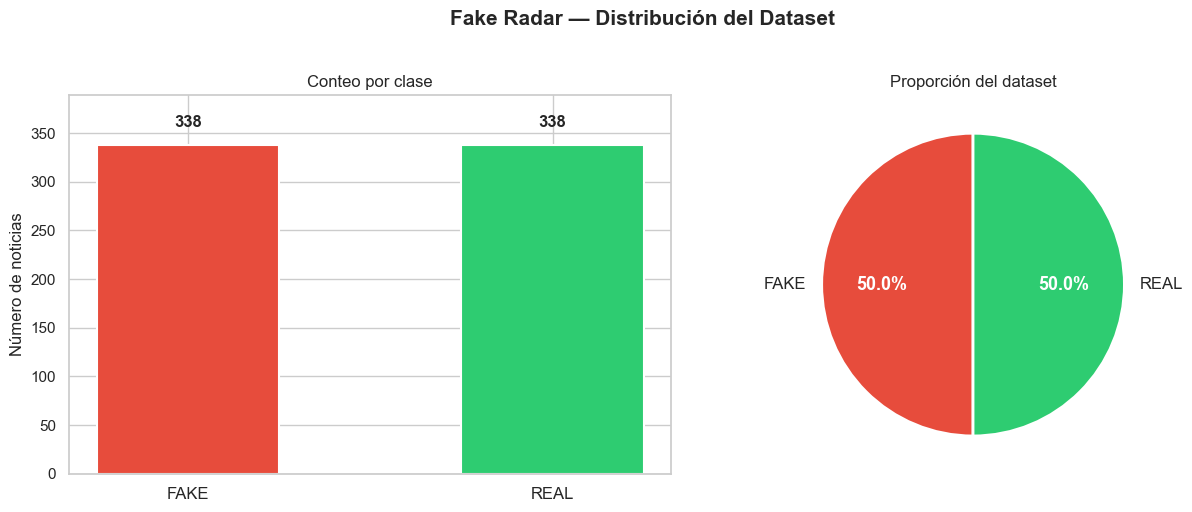

✅ Gráfica 1 generada


In [5]:
# ============================================================
# GRÁFICA 1: Distribución de clases
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Fake Radar — Distribución del Dataset', fontsize=15, fontweight='bold', y=1.02)

# Conteo
counts = df['label_name'].value_counts()
counts = counts.reindex(['FAKE','REAL'])  # orden fijo: FAKE primero
colors = [COLOR_FAKE, COLOR_REAL]

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Conteo por clase', fontsize=12)
axes[0].set_ylabel('Número de noticias')
axes[0].set_ylim(0, max(counts.values) * 1.15)
axes[0].tick_params(axis='x', labelsize=12)

# Proporción
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')
axes[1].set_title('Proporción del dataset', fontsize=12)

plt.tight_layout()
plt.savefig('./plot_01_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica 1 generada')

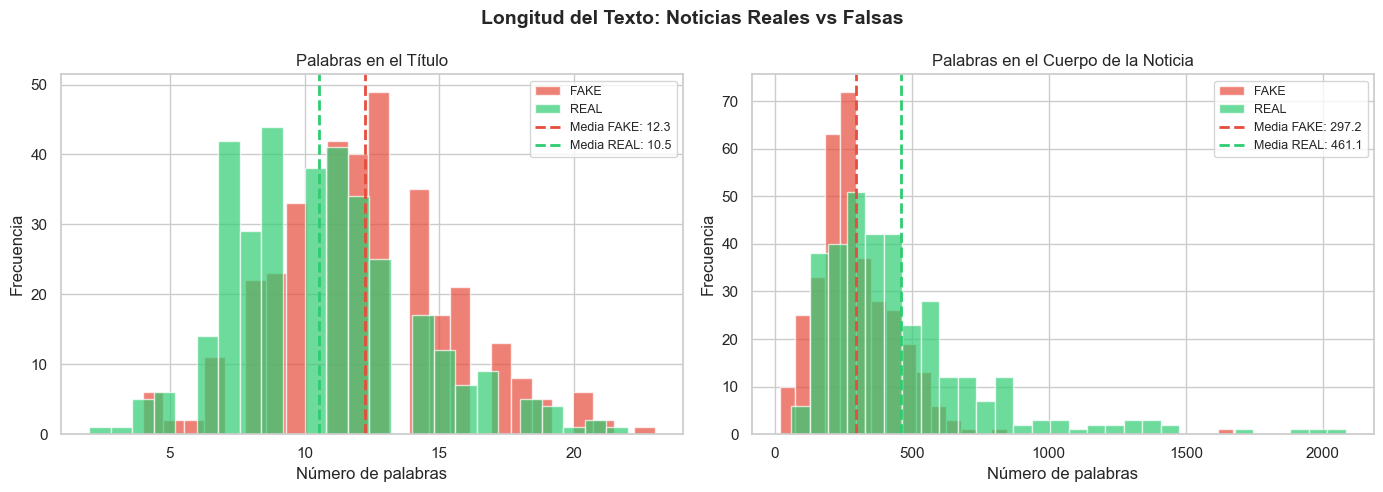

✅ Gráfica 2 generada


In [6]:
# ============================================================
# GRÁFICA 2: Longitud de textos — Real vs Fake
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Longitud del Texto: Noticias Reales vs Falsas', fontsize=14, fontweight='bold')

fake_df = df[df.label == 0]
real_df = df[df.label == 1]

# Longitud del título
axes[0].hist(fake_df['title_clean_len'], bins=25, color=COLOR_FAKE, alpha=0.7, label='FAKE', edgecolor='white')
axes[0].hist(real_df['title_clean_len'], bins=25, color=COLOR_REAL, alpha=0.7, label='REAL', edgecolor='white')
axes[0].axvline(fake_df['title_clean_len'].mean(), color=COLOR_FAKE, linestyle='--', linewidth=2,
                label=f'Media FAKE: {fake_df["title_clean_len"].mean():.1f}')
axes[0].axvline(real_df['title_clean_len'].mean(), color=COLOR_REAL, linestyle='--', linewidth=2,
                label=f'Media REAL: {real_df["title_clean_len"].mean():.1f}')
axes[0].set_title('Palabras en el Título', fontsize=12)
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Longitud del cuerpo
axes[1].hist(fake_df['text_clean_len'], bins=30, color=COLOR_FAKE, alpha=0.7, label='FAKE', edgecolor='white')
axes[1].hist(real_df['text_clean_len'], bins=30, color=COLOR_REAL, alpha=0.7, label='REAL', edgecolor='white')
axes[1].axvline(fake_df['text_clean_len'].mean(), color=COLOR_FAKE, linestyle='--', linewidth=2,
                label=f'Media FAKE: {fake_df["text_clean_len"].mean():.1f}')
axes[1].axvline(real_df['text_clean_len'].mean(), color=COLOR_REAL, linestyle='--', linewidth=2,
                label=f'Media REAL: {real_df["text_clean_len"].mean():.1f}')
axes[1].set_title('Palabras en el Cuerpo de la Noticia', fontsize=12)
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('./plot_02_longitud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica 2 generada')

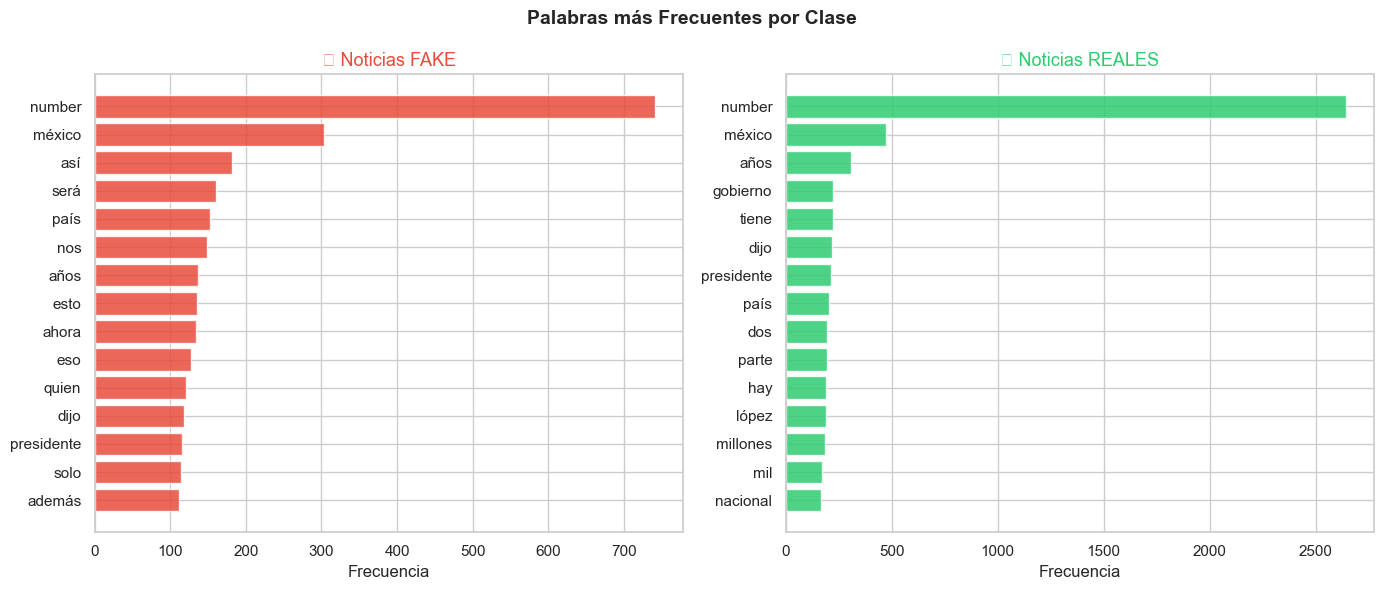

✅ Gráfica 3 generada


In [7]:
# ============================================================
# GRÁFICA 3: Palabras más frecuentes por clase
# ============================================================

def get_top_words(texts, n=15, exclude=None):
    """Obtiene las N palabras más frecuentes de una serie de textos."""
    # Stopwords en ESPAÑOL — palabras muy comunes que no aportan significado
    stopwords = {
        'el','la','los','las','un','una','unos','unas',
        'de','del','en','con','por','para','que','qué',
        'es','son','fue','ser','está','están','ha','han',
        'se','su','sus','le','les','lo','al','y','o','a',
        'no','si','más','pero','como','cuando','donde',
        'este','esta','estos','estas','ese','esa','esos',
        'ya','también','muy','todo','todos','toda','todas',
        'porque','sobre','entre','hasta','desde','durante',
        'según','ante','tras','sin','ni','e','u','aunque'
    }
    if exclude:
        stopwords.update(exclude)
    all_words = ' '.join(texts).split()
    filtered  = [w for w in all_words if w not in stopwords and len(w) > 2]
    return Counter(filtered).most_common(n)

fake_df = df[df.label == 0]
real_df = df[df.label == 1]

top_fake = get_top_words(fake_df['text_clean'])
top_real = get_top_words(real_df['text_clean'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Palabras más Frecuentes por Clase', fontsize=14, fontweight='bold')

# FAKE
words_f, counts_f = zip(*top_fake)
y_pos = range(len(words_f))
axes[0].barh(y_pos, counts_f, color=COLOR_FAKE, alpha=0.85, edgecolor='white')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(words_f, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_title('🔴 Noticias FAKE', fontsize=13, color=COLOR_FAKE)
axes[0].set_xlabel('Frecuencia')

# REAL
words_r, counts_r = zip(*top_real)
axes[1].barh(y_pos, counts_r, color=COLOR_REAL, alpha=0.85, edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(words_r, fontsize=11)
axes[1].invert_yaxis()
axes[1].set_title('🟢 Noticias REALES', fontsize=13, color=COLOR_REAL)
axes[1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.savefig('./plot_03_palabras.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica 3 generada')


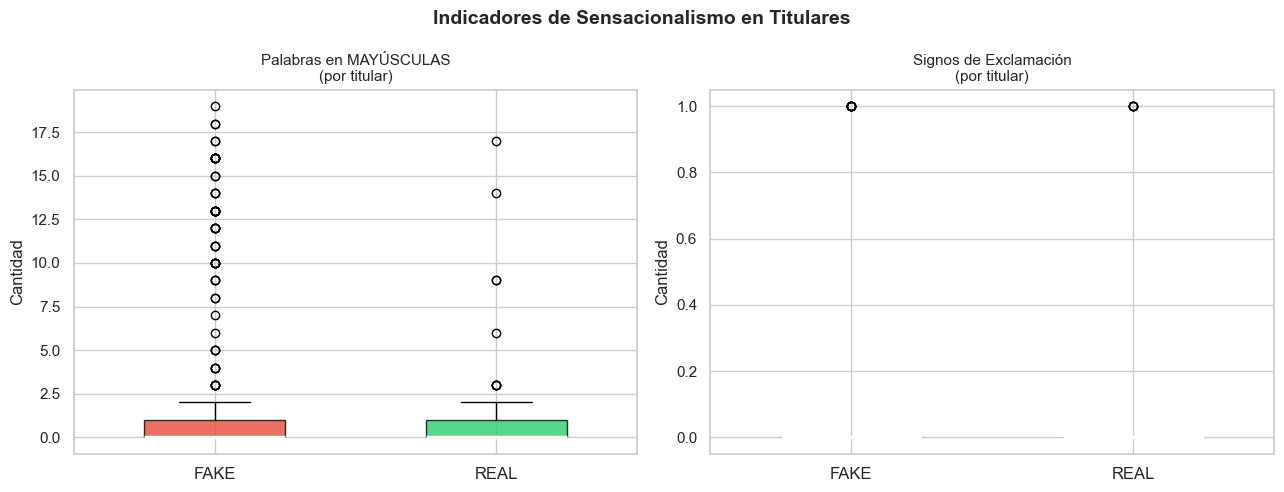

✅ Gráfica 4 generada


In [8]:
# ============================================================
# GRÁFICA 4: Indicadores lingüísticos de sensacionalismo
# Palabras en MAYÚSCULAS y signos de exclamación
# ============================================================

def count_caps_words(text):
    """Cuenta palabras completamente en mayúsculas (señal de sensacionalismo)."""
    if not isinstance(text, str): return 0
    return sum(1 for w in text.split() if w.isupper() and len(w) > 1)

def count_exclamations(text):
    """Cuenta signos de exclamación en el texto."""
    if not isinstance(text, str): return 0
    return text.count('!')

df['caps_words']   = df['title'].apply(count_caps_words)
df['exclamations'] = df['title'].apply(count_exclamations)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Indicadores de Sensacionalismo en Titulares', fontsize=14, fontweight='bold')

# Palabras en mayúsculas
caps_fake = df[df.label==0]['caps_words']
caps_real = df[df.label==1]['caps_words']
data_caps = [caps_fake.values, caps_real.values]
bp1 = axes[0].boxplot(data_caps, patch_artist=True, widths=0.5,
                      medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp1['boxes'], [COLOR_FAKE, COLOR_REAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_xticklabels(['FAKE', 'REAL'], fontsize=12)
axes[0].set_title('Palabras en MAYÚSCULAS\n(por titular)', fontsize=11)
axes[0].set_ylabel('Cantidad')

# Signos de exclamación
exc_fake = df[df.label==0]['exclamations']
exc_real = df[df.label==1]['exclamations']
data_exc = [exc_fake.values, exc_real.values]
bp2 = axes[1].boxplot(data_exc, patch_artist=True, widths=0.5,
                      medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp2['boxes'], [COLOR_FAKE, COLOR_REAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticklabels(['FAKE', 'REAL'], fontsize=12)
axes[1].set_title('Signos de Exclamación\n(por titular)', fontsize=11)
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.savefig('./plot_04_sensacionalismo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica 4 generada')

In [9]:
# ============================================================
# GRÁFICA 5: Estadísticas comparativas — tabla resumen
# ============================================================

# Asegurarnos de que las columnas existan (por si el kernel se reinició)
if 'caps_words' not in df.columns:
    df['caps_words']   = df['title'].apply(count_caps_words)
if 'exclamations' not in df.columns:
    df['exclamations'] = df['title'].apply(count_exclamations)

# Separar fake y real
fake_df = df[df.label == 0]
real_df = df[df.label == 1]

stats = pd.DataFrame({
    'Métrica': [
        'Total de noticias',
        'Palabras promedio en titular',
        'Palabras promedio en cuerpo',
        'Palabras MAYÚSCULAS promedio',
        'Signos de exclamación promedio',
    ],
    'FAKE 🔴': [
        f"{len(fake_df):,}",
        f"{fake_df['title_clean_len'].mean():.1f}",
        f"{fake_df['text_clean_len'].mean():.1f}",
        f"{fake_df['caps_words'].mean():.2f}",
        f"{fake_df['exclamations'].mean():.2f}",
    ],
    'REAL 🟢': [
        f"{len(real_df):,}",
        f"{real_df['title_clean_len'].mean():.1f}",
        f"{real_df['text_clean_len'].mean():.1f}",
        f"{real_df['caps_words'].mean():.2f}",
        f"{real_df['exclamations'].mean():.2f}",
    ]
})

print('\n📊 TABLA RESUMEN ESTADÍSTICO\n')
print(stats.to_string(index=False))

# Exportar dataset limpio
output_cols = ['title', 'text', 'label', 'label_name', 
               'title_clean', 'text_clean',
               'title_clean_len', 'text_clean_len', 
               'caps_words', 'exclamations']

df[output_cols].to_csv('./fakenews_dataset_clean.csv', index=False)

print(f'\n✅ Dataset limpio exportado → fakenews_dataset_clean.csv ({len(df):,} filas)')


📊 TABLA RESUMEN ESTADÍSTICO

                       Métrica FAKE 🔴 REAL 🟢
             Total de noticias    338    338
  Palabras promedio en titular   12.3   10.5
   Palabras promedio en cuerpo  297.2  461.1
  Palabras MAYÚSCULAS promedio   2.35   0.59
Signos de exclamación promedio   0.03   0.01

✅ Dataset limpio exportado → fakenews_dataset_clean.csv (676 filas)


---
## 5. Hallazgos del EDA

El análisis estadístico reveló diferencias significativas entre las dos clases:

- **Longitud de texto:** las noticias falsas presentan titulares más cortos y cuerpos menos extensos en comparación con las reales.
- **Indicadores de sensacionalismo:** mayor frecuencia de palabras en mayúsculas y signos de exclamación en la clase *fake*.
- **Vocabulario diferenciado:** la clase *fake* concentra términos emotivos y alarmistas; la clase *real* emplea léxico institucional y periodístico.

| Característica | Estado |
|----------------|--------|
| Idioma del corpus | Español ✅ |
| Balance de clases | Balanceado (~50/50) ✅ |
| Texto normalizado | Minúsculas, sin HTML/URLs, tildes conservadas ✅ |
| Archivo de salida | `fakenews_dataset_clean.csv` ✅ |

---

## 6. Salida del notebook

El archivo `fakenews_dataset_clean.csv` generado en la sección anterior es el insumo directo
para el notebook de entrenamiento (`fake_radar_modelo.ipynb`).

---
*Fake Radar — Instituto Tecnológico de Tijuana — Enero-Junio 2026*
